In [2]:
import pandas as pd
import numpy as np
np.random.seed(42)

n = 2000

df = pd.DataFrame({
    "User_ID": range(1, n+1),
    "Visited": np.random.choice([1, 0], n, p=[0.95, 0.05]),
    "Signed_Up": np.random.choice([1, 0], n, p=[0.7, 0.3]),
    "Added_to_Cart": np.random.choice([1, 0], n, p=[0.5, 0.5]),
    "Purchased": np.random.choice([1, 0], n, p=[0.3, 0.7])
})

df.to_csv('funnel.csv', index=False)

df.head()

,User_ID,Visited,Signed_Up,Added_to_Cart,Purchased
0,1,1,1,0,0
1,2,0,1,0,1
2,3,1,0,0,0
3,4,1,1,1,0
4,5,1,1,1,1


In [3]:
df = pd.read_csv('funnel.csv')
df.head()

,User_ID,Visited,Signed_Up,Added_to_Cart,Purchased
0,1,1,1,0,0
1,2,0,1,0,1
2,3,1,0,0,0
3,4,1,1,1,0
4,5,1,1,1,1


In [ ]:
Total user at each stages:

In [4]:
df.sum()

User_ID          2001000
Visited             1895
Signed_Up           1408
Added_to_Cart       1010
Purchased            619
dtype: int64

In [5]:
stages = ['Visited', 'Signed_Up', 'Added_to_Cart', 'Purchased']
values = [df[col].sum() for col in stages]

for stage, value in zip(stages, values):
    print(stage, ":", value)

Visited : 1895
Signed_Up : 1408
Added_to_Cart : 1010
Purchased : 619


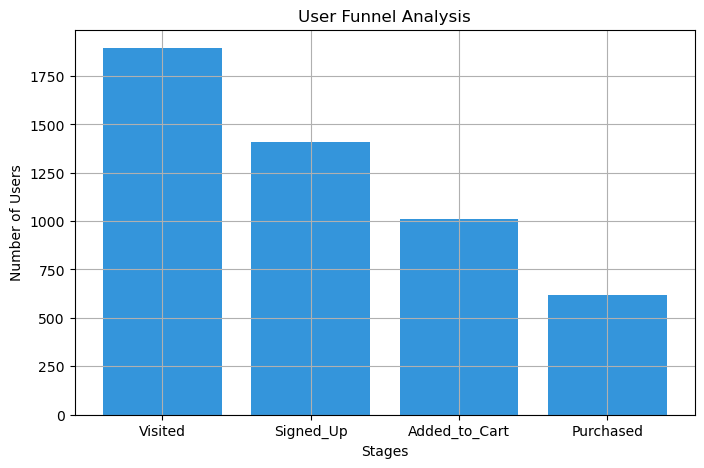

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(stages, values, color='#3495DB')

plt.title("User Funnel Analysis")
plt.xlabel("Stages")
plt.ylabel("Number of Users")

plt.grid(True)
plt.savefig('funnel_chart.png')
plt.show()

In [8]:
visit_to_signup = values[1] / values[0]
signup_to_cart = values[2] / values[1]
cart_to_purchase = values[3] / values[2]

print("Visit → Signup:", visit_to_signup)
print("Signup → Cart:", signup_to_cart)
print("Cart → Purchase:", cart_to_purchase)

Visit → Signup: 0.7430079155672823
Signup → Cart: 0.7173295454545454
Cart → Purchase: 0.6128712871287129


In [9]:
drop_signup = 1 - visit_to_signup
drop_cart = 1 - signup_to_cart
drop_purchase = 1 - cart_to_purchase

print("Drop at Signup:", drop_signup)
print("Drop at Cart:", drop_cart)
print("Drop at Purchase:", drop_purchase)

Drop at Signup: 0.2569920844327177
Drop at Cart: 0.2826704545454546
Drop at Purchase: 0.38712871287128714
